In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Dados Banco Central do Brasil

In [2]:
df_bcb = pd.read_parquet("data/processed/bcb_credit_sample.parquet")
df_bcb.head()

,data_base,uf,segmento,cliente,cnae_ocupacao,porte,modalidade,submodalidade,origem,indexador,...,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,target_default
0,2026-05-31,AC,Banco,PF,Empresário,Acima de 20 salários mínimos,Financiamentos,Aquisição de bens - veículos automotores,Sem destinação específica,Índices de preços,...,0.00,0.00,1011671.54,0.00,0.00,0.00,1011671.54,0.00,0.00,0
1,2026-04-30,AC,Financeira,PJ,"Artes, cultura, esporte e recreação",Pequeno,Empréstimos,Capital de giro com prazo de vencimento superi...,Sem destinação específica,Prefixado,...,0.00,0.00,1680.07,0.00,0.00,0.00,1680.07,0.00,1680.07,0
2,2025-11-30,AC,Outros,PF,Servidor ou empregado público,Mais de 10 a 20 salários mínimos,Financiamentos imobiliários,Financiamento habitacional - SFH,Com destinação específica,Pós-fixado,...,631707.47,234450.32,1300892.91,3150.18,0.00,3150.18,1304043.09,0.00,0.00,0
3,2025-10-31,AC,Banco,PF,Empregado de empresa privada,Mais de 2 a 3 salários mínimos,Financiamentos,Cartão de crédito - compra ou fatura parcelada...,Sem destinação específica,Prefixado,...,0.00,649.81,649.81,0.00,0.00,0.00,649.81,0.00,0.00,0
4,2026-07-31,AC,Banco,PJ,Atividades administrativas e serviços compleme...,Pequeno,Empréstimos,Outros empréstimos,Sem destinação específica,Pós-fixado,...,15375.51,0.00,65968.76,3488.29,23971.65,27459.94,93428.70,92536.52,93428.70,1


In [3]:
df_bcb.columns

Index(['data_base', 'uf', 'segmento', 'cliente', 'cnae_ocupacao', 'porte',
       'modalidade', 'submodalidade', 'origem', 'indexador',
       'numero_de_operacoes', 'a_vencer_ate_90_dias',
       'a_vencer_de_91_ate_360_dias', 'a_vencer_de_361_ate_1080_dias',
       'a_vencer_de_1081_ate_1800_dias', 'a_vencer_de_1801_ate_5400_dias',
       'a_vencer_acima_de_5400_dias', 'carteira_a_vencer',
       'vencido_de_15_ate_90_dias', 'vencido_acima_de_90_dias',
       'carteira_vencida', 'carteira_ativa', 'carteira_inadimplencia',
       'ativo_problematico', 'target_default'],
      dtype='object')

In [4]:
origens = df_bcb['origem'].unique()
print(origens)

['Sem destinação específica' 'Com destinação específica']


In [5]:
submodalidades = df_bcb['submodalidade'].unique()
print(submodalidades)

['Aquisição de bens - veículos automotores'
 'Capital de giro com prazo de vencimento superior a 365 dias'
 'Financiamento habitacional - SFH'
 'Cartão de crédito - compra ou fatura parcelada pela instituição financeira emitente do cartão'
 'Outros empréstimos'
 'Cartão de crédito - compra, fatura parcelada ou saque financiado pela instituição financeira emitente do cartão'
 'Cartão de crédito - compra à vista e parcelado lojista '
 'Cartão de crédito - não migrado' 'Avais e fianças honrados'
 'Crédito pessoal - com consignação em folha de pagam.'
 'Financiamento habitacional \x96 exceto SFH' 'Cheque especial' 'Vendor'
 'Custeio' 'Crédito rotativo vinculado a cartão de crédito' 'Microcrédito'
 'Outros títulos descontados'
 'Crédito pessoal - sem consignação em folha de pagam.'
 'Outros com característica de crédito' 'Adiantamentos a depositantes'
 'Aquisição de bens - outros bens' 'Outros financiamentos'
 'Desconto de duplicatas' 'Conta Garantida' 'Compror' 'Investimento'
 'Recebíveis 

In [6]:
df_bcb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29924 entries, 0 to 29923
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data_base                       29924 non-null  datetime64[ns]
 1   uf                              29924 non-null  object        
 2   segmento                        29924 non-null  object        
 3   cliente                         29924 non-null  object        
 4   cnae_ocupacao                   29924 non-null  object        
 5   porte                           29924 non-null  object        
 6   modalidade                      29924 non-null  object        
 7   submodalidade                   29924 non-null  object        
 8   origem                          29924 non-null  object        
 9   indexador                       29924 non-null  object        
 10  numero_de_operacoes             29924 non-null  int64         
 11  a_

## Financial Risk for Loan Approval Dataset (Análise de Crédito)

In [7]:
df_loan = pd.read_csv("data/processed/loan_approval_data.csv")
df_loan.head()

,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,...,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,loan_status
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,1


In [8]:
df_loan.columns

Index(['applicationdate', 'age', 'annualincome', 'creditscore',
       'employmentstatus', 'educationlevel', 'experience', 'loanamount',
       'loanduration', 'maritalstatus', 'numberofdependents',
       'homeownershipstatus', 'monthlydebtpayments',
       'creditcardutilizationrate', 'numberofopencreditlines',
       'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory',
       'loanpurpose', 'previousloandefaults', 'paymenthistory',
       'lengthofcredithistory', 'savingsaccountbalance',
       'checkingaccountbalance', 'totalassets', 'totalliabilities',
       'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth',
       'baseinterestrate', 'interestrate', 'monthlyloanpayment',
       'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'loan_status'],
      dtype='object')

In [9]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   applicationdate             20000 non-null  object 
 1   age                         20000 non-null  int64  
 2   annualincome                20000 non-null  int64  
 3   creditscore                 20000 non-null  int64  
 4   employmentstatus            20000 non-null  object 
 5   educationlevel              20000 non-null  object 
 6   experience                  20000 non-null  int64  
 7   loanamount                  20000 non-null  int64  
 8   loanduration                20000 non-null  int64  
 9   maritalstatus               20000 non-null  object 
 10  numberofdependents          20000 non-null  int64  
 11  homeownershipstatus         20000 non-null  object 
 12  monthlydebtpayments         20000 non-null  int64  
 13  creditcardutilizationrate   200

In [10]:
df_loan.describe()

,age,annualincome,creditscore,experience,loanamount,loanduration,numberofdependents,monthlydebtpayments,creditcardutilizationrate,numberofopencreditlines,...,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,loan_status
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780,0.239000
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262,0.426483
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000,0.000000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000,0.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000,0.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000,0.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000,1.000000


In [11]:
df_loan.isnull().sum()

applicationdate               0
age                           0
annualincome                  0
creditscore                   0
employmentstatus              0
educationlevel                0
experience                    0
loanamount                    0
loanduration                  0
maritalstatus                 0
numberofdependents            0
homeownershipstatus           0
monthlydebtpayments           0
creditcardutilizationrate     0
numberofopencreditlines       0
numberofcreditinquiries       0
debttoincomeratio             0
bankruptcyhistory             0
loanpurpose                   0
previousloandefaults          0
paymenthistory                0
lengthofcredithistory         0
savingsaccountbalance         0
checkingaccountbalance        0
totalassets                   0
totalliabilities              0
monthlyincome                 0
utilitybillspaymenthistory    0
jobtenure                     0
networth                      0
baseinterestrate              0
interest

In [12]:
df_loan['loan_status'].value_counts(normalize=True)

loan_status
0    0.761
1    0.239
Name: proportion, dtype: float64

C:\Users\adria\AppData\Local\Temp\ipykernel_31968\3114185218.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(12), palette='viridis')


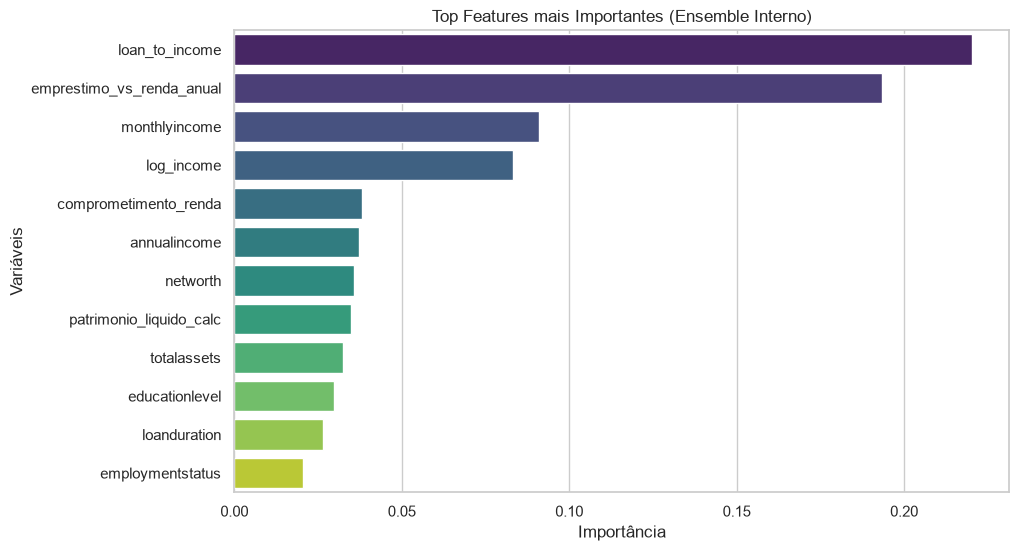

Threshold Otimizado Aplicado: 0.4618

              precision    recall  f1-score   support

  Denied (0)       0.98      0.87      0.92      3044
Approved (1)       0.70      0.93      0.80       956

    accuracy                           0.89      4000
   macro avg       0.84      0.90      0.86      4000
weighted avg       0.91      0.89      0.89      4000



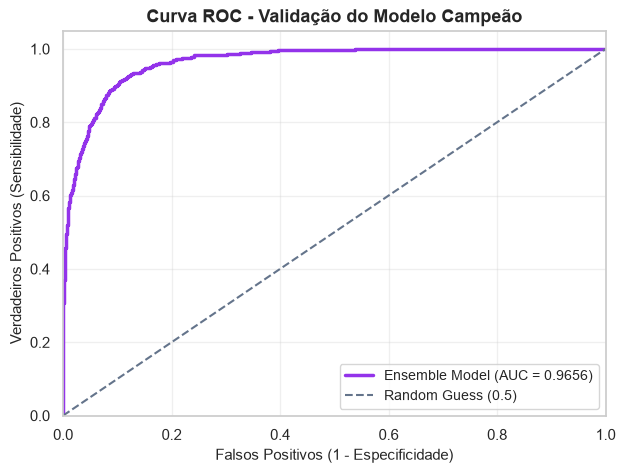

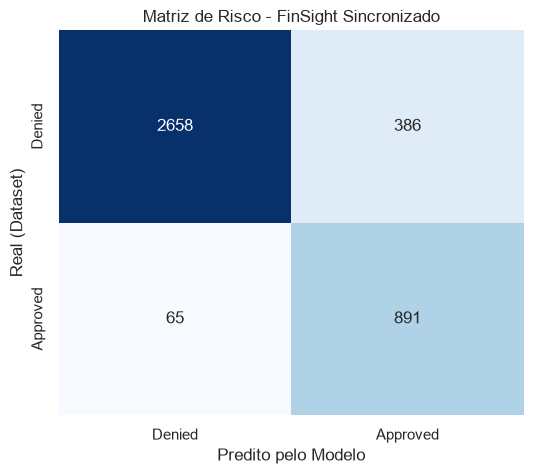

In [ ]:
import joblib
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from src.models import EnsembleClassifier
sys.modules['models'] = sys.modules['src.models']

def feature_engineering_avancada_notebook(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    drop_features = [
        "applicationdate", "creditscore", "bankruptcyhistory", "previousloandefaults", 
        "paymenthistory", "lengthofcredithistory", "numberofopencreditlines", 
        "numberofcreditinquiries", "debttoincomeratio", "totaldebttoincomeratio",
        "baseinterestrate", "interestrate", "monthlyloanpayment", "riskscore",
        "loanapproved", "loan_approved", "loan_status"
    ]
    df.drop(columns=[c for c in drop_features if c in df.columns], inplace=True, errors="ignore")

    num_cols = ["age", "annualincome", "experience", "loanamount", "loanduration", 
                "numberofdependents", "monthlydebtpayments", "creditcardutilizationrate",
                "savingsaccountbalance", "checkingaccountbalance", "totalassets", 
                "totalliabilities", "monthlyincome", "jobtenure", "networth"]
    
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    if "annualincome" in df.columns and "loanamount" in df.columns:
        df["loan_to_income"] = df["loanamount"] / (df["annualincome"] + 1.0)
        df["log_income"] = np.log1p(df["annualincome"])
        df["log_loan"] = np.log1p(df["loanamount"])

    if "experience" in df.columns and "age" in df.columns:
        df["career_stability_ratio"] = df["experience"] / (df["age"] + 1.0)

    str_cols = df.select_dtypes(include=["object", "category"]).columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

    return df

df_raw = pd.read_csv("data/processed/loan_approval_data.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
target_col = "loanapproved" if "loanapproved" in df_raw.columns else "loan_status"

y = pd.to_numeric(df_raw[target_col], errors="coerce").fillna(0).astype(int)

df_features = feature_engineering_avancada_notebook(df_raw)

if 'monthlydebtpayments' in df_features.columns and 'monthlyincome' in df_features.columns:
    df_features['comprometimento_renda'] = df_features['monthlydebtpayments'] / (df_features['monthlyincome'] + 1e-5)
if 'totalassets' in df_features.columns and 'totalliabilities' in df_features.columns:
    df_features['patrimonio_liquido_calc'] = df_features['totalassets'] - df_features.get('totalliabilities', 0)
if 'loanamount' in df_features.columns and 'annualincome' in df_features.columns:
    df_features['emprestimo_vs_renda_anual'] = df_features['loanamount'] / (df_features['annualincome'] + 1e-5)
if 'savingsaccountbalance' in df_features.columns and 'checkingaccountbalance' in df_features.columns and 'monthlydebtpayments' in df_features.columns:
    soma_saldos = df_features['savingsaccountbalance'] + df_features['checkingaccountbalance']
    df_features['cobertura_liquidez'] = soma_saldos / (df_features['monthlydebtpayments'] + 1e-5)

X = df_features.drop(columns=[target_col], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = joblib.load("artifacts/champion_model.pkl")

try:
    internal_model = None
    preprocessor = None
    if hasattr(pipeline, "model_xgb"):
        internal_model = pipeline.model_xgb.named_steps.get("model", None)
        preprocessor = pipeline.model_xgb.named_steps.get("preprocessor", None)
    elif hasattr(pipeline, "model_cat"):
        internal_model = pipeline.model_cat.named_steps.get("model", None)
        preprocessor = pipeline.model_cat.named_steps.get("preprocessor", None)

    if internal_model and preprocessor:
        cat_transformer = preprocessor.named_transformers_.get("cat", None)
        cat_cols_encoded = cat_transformer.get_feature_names_out() if cat_transformer and hasattr(cat_transformer, "get_feature_names_out") else X.select_dtypes(include=["object", "category"]).columns
        num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
        feature_names = list(num_cols) + list(cat_cols_encoded)

        if hasattr(internal_model, "feature_importances_"):
            importances = internal_model.feature_importances_
            if len(importances) == len(feature_names):
                feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
                feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

                plt.figure(figsize=(10, 6))
                sns.barplot(x='Importance', y='Feature', data=feat_imp.head(12), palette='viridis')
                plt.title("Top Features mais Importantes (Ensemble Interno)")
                plt.xlabel("Importância")
                plt.ylabel("Variáveis")
                plt.show()
except Exception as e:
    print(f"Aviso ao plotar importâncias: {e}")

test_proba = pipeline.predict_proba(X_test)[:, 1]

best_threshold = 0.4618
y_pred = (test_proba >= best_threshold).astype(int)

print(f"Threshold Otimizado Aplicado: {best_threshold}\n")
print(classification_report(y_test, y_pred, target_names=["Denied (0)", "Approved (1)"]))

auc_score = roc_auc_score(y_test, test_proba)
fpr, tpr, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#9333ea', lw=2.5, label=f'Ensemble Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='#64748b', lw=1.5, linestyle='--', label='Random Guess (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsos Positivos (1 - Especificidade)', fontsize=11)
plt.ylabel('Verdadeiros Positivos (Sensibilidade)', fontsize=11)
plt.title('Curva ROC - Validação do Modelo Campeão', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Denied", "Approved"],
            yticklabels=["Denied", "Approved"])
plt.xlabel("Predito pelo Modelo")
plt.ylabel("Real (Dataset)")
plt.title("Matriz de Risco - FinSight Sincronizado")
plt.show()

## Fraude e Pix

In [ ]:
df_fraud = pd.read_parquet("data/processed/pix_fraud_sample.parquet")
df_fraud.columns

Index(['anomes', 'qtdepixcontestados', 'qtdecontestacoesaceitas',
       'qtdecontestacoesrejeitadas', 'qtdecontestacoesaceitasacada100mil',
       'qtdeusuarioscommarcacoesdefraude', 'qtdechavespixcommarcacoesdefraude',
       'valorpixcontestadosaceitos',
       'quantidadedevolvidaintegralmentepormeiodomed',
       'valorpixdevolvidosintegralmente',
       'quantidadedevolvidaparcialmentepormeiodomed',
       'valorpixdevolvidosparcialmente', 'valorpixresidualnaodevolvido',
       'quantidadedenaodevolvidossaldoinsuficiente',
       'valorpixnaodevolvidossaldoinsuficiente',
       'quantidadedenaodevolvidoscontaencerrada',
       'valornaodevolvidoscontaencerrada',
       'quantidadedenaodevolvidosmotivosdiversos',
       'valorpixnaodevolvidosmotivosdiversos', 'percentualdedevolucao',
       'qtdepixbloqueadoscautelarmenteeliberados',
       'valorpixbloqueadoscautelarmenteeliberados',
       'qtdepixbloqueadoscautelarmenteedevolvidos',
       'valorpixbloqueadoscautelarmenteedevol

In [ ]:
df_fraud.shape

(5, 24)

In [ ]:
df_pix = pd.read_parquet("data/processed/pix_transacoes_sample.parquet")
df_pix.columns

Index(['anomes', 'pag_pfpj', 'rec_pfpj', 'pag_regiao', 'rec_regiao',
       'pag_idade', 'rec_idade', 'formainiciacao', 'natureza', 'finalidade',
       'valor', 'quantidade'],
      dtype='object')

In [ ]:
finalidades = df_pix['finalidade'].unique()
print(finalidades)